# Анализ продаж магазина Superstore

## О проекте

Анализ данных о продажах интернет-магазина за 2015-2018 годы для выявления ключевых драйверов роста и разработки рекомендаций по увеличению выручки.

**Датасет:** Superstore Sales Dataset (9,800 записей, 18 признаков)

**Инструменты:** Python, Pandas, Matplotlib, Seaborn

**Задачи:**
- Проанализировать структуру продаж
- Выявить наиболее прибыльные категории и регионы
- Оценить динамику роста
- Разработать рекомендации для бизнеса

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Загрузка и первичный анализ данных

In [5]:
df = pd.read_csv('superstore_data.csv')

print(f"Строк: {len(df)}")
print(f"Колонок: {len(df.columns)}")
df.head()

Строк: 9800
Колонок: 18


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


In [6]:
print("Типы данных:")
print(df.dtypes)
print("\nСтатистика по продажам:")
print(df['sales'].describe())

Типы данных:
row_id             int64
order_id          object
order_date        object
ship_date         object
ship_mode         object
customer_id       object
customer_name     object
segment           object
country           object
city              object
state             object
postal_code      float64
region            object
product_id        object
category          object
sub_category      object
product_name      object
sales            float64
dtype: object

Статистика по продажам:
count     9800.000000
mean       230.769079
std        626.651906
min          0.440000
25%         17.250000
50%         54.490000
75%        210.605000
max      22638.480000
Name: sales, dtype: float64


## 1. Распределение продаж

Анализ распределения сумм заказов для понимания структуры выручки.

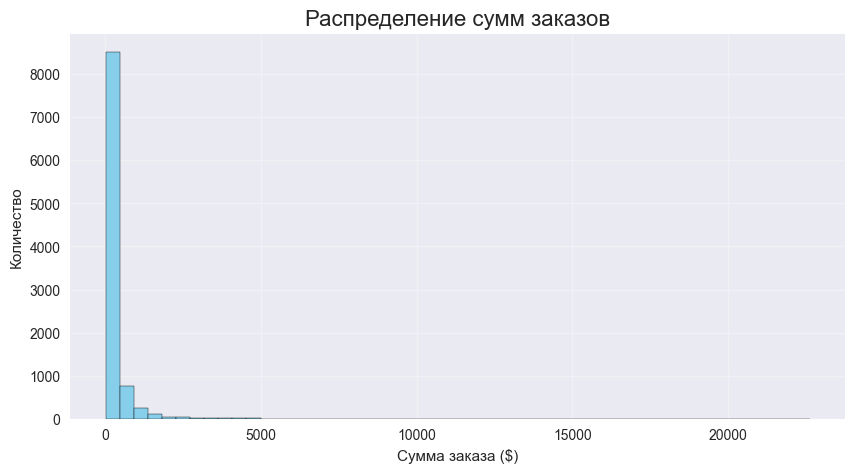

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df['sales'], bins=50, color='skyblue', edgecolor='black')
plt.title('Распределение сумм заказов', fontsize=16)
plt.xlabel('Сумма заказа ($)')
plt.ylabel('Количество')
plt.grid(alpha=0.3)
plt.show()

**Выводы:**

- Большинство заказов находятся в диапазоне до $500

- Распределение имеет длинный правый хвост - присутствуют крупные заказы до $22K

- Средний чек составляет $231

## 2. Продажи по категориям товаров

Определение наиболее прибыльных категорий.

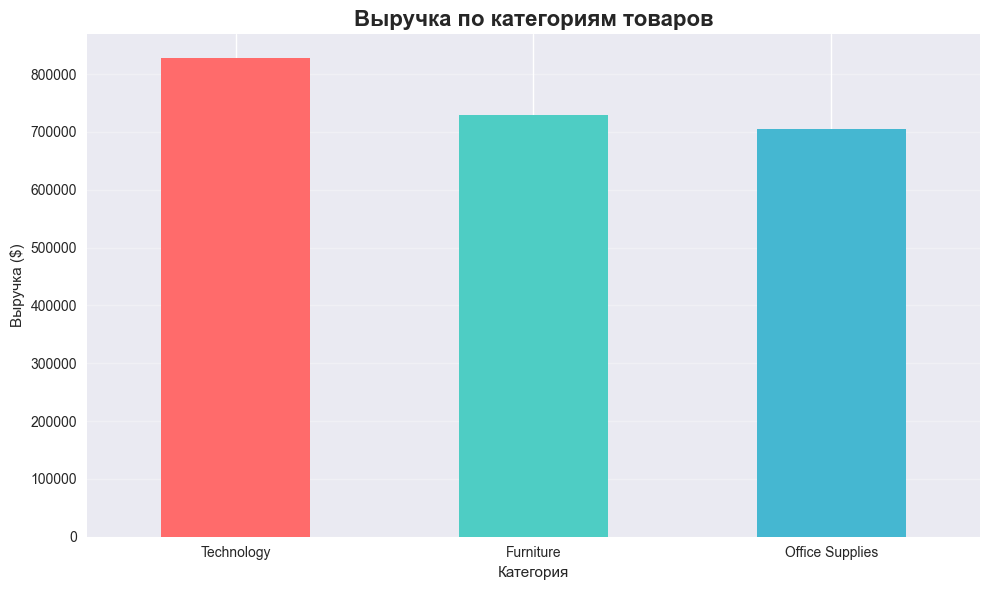

In [9]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Выручка по категориям товаров', fontsize=16, fontweight='bold')
plt.xlabel('Категория')
plt.ylabel('Выручка ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Выводы:**

- Technology лидирует с выручкой $827K (36% от общей)

- Furniture и Office Supplies показывают сопоставимые результаты ($729K и $705K)

- Рекомендуется усилить фокус на категории Technology

## 3. Динамика продаж по годам

Оценка тренда развития бизнеса.

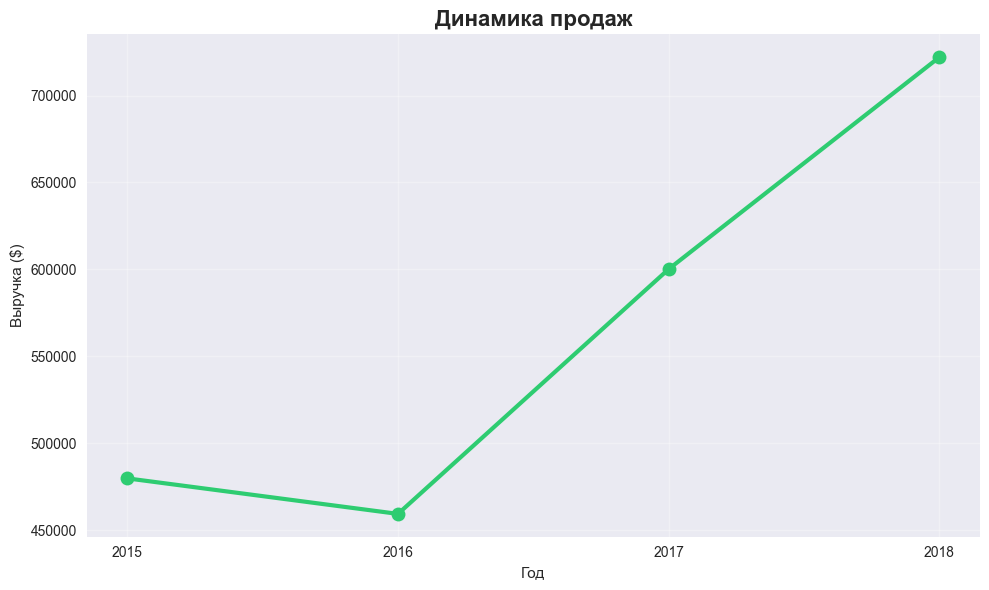

In [10]:
df['year'] = pd.to_datetime(df['order_date']).dt.year
yearly_sales = df.groupby('year')['sales'].sum()

plt.figure(figsize=(10, 6))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', linewidth=3, 
         markersize=10, color='#2ecc71')
plt.title('Динамика продаж', fontsize=16, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Выручка ($)')
plt.xticks(yearly_sales.index)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Выводы:**

- Позитивный тренд роста с 2015 по 2018

- Выручка выросла с 480K до 722K  (+50%)

- Небольшой спад в 2016 году компенсирован ростом в 2017-2018

## 4. Топ-10 регионов по продажам

Географический анализ выручки.

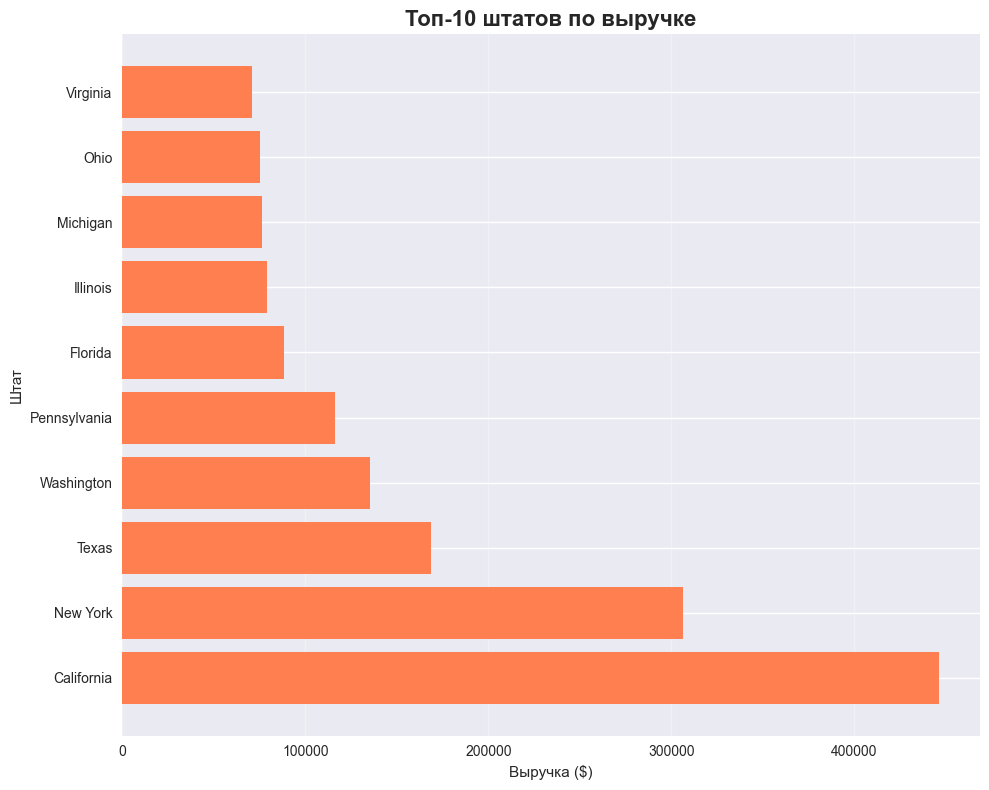

In [11]:
state_sales = df.groupby('state')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 8))
plt.barh(state_sales.index, state_sales.values, color='coral')
plt.title('Топ-10 штатов по выручке', fontsize=16, fontweight='bold')
plt.xlabel('Выручка ($)')
plt.ylabel('Штат')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Выводы:**

- California безусловный лидер с выручкой $446K (20% от общей)

- New York и Texas занимают 2-е и 3-е места ($306K и $169K)

- Западное и Восточное побережья - ключевые рынки

## 5. Структура клиентской базы

Распределение выручки по сегментам клиентов.

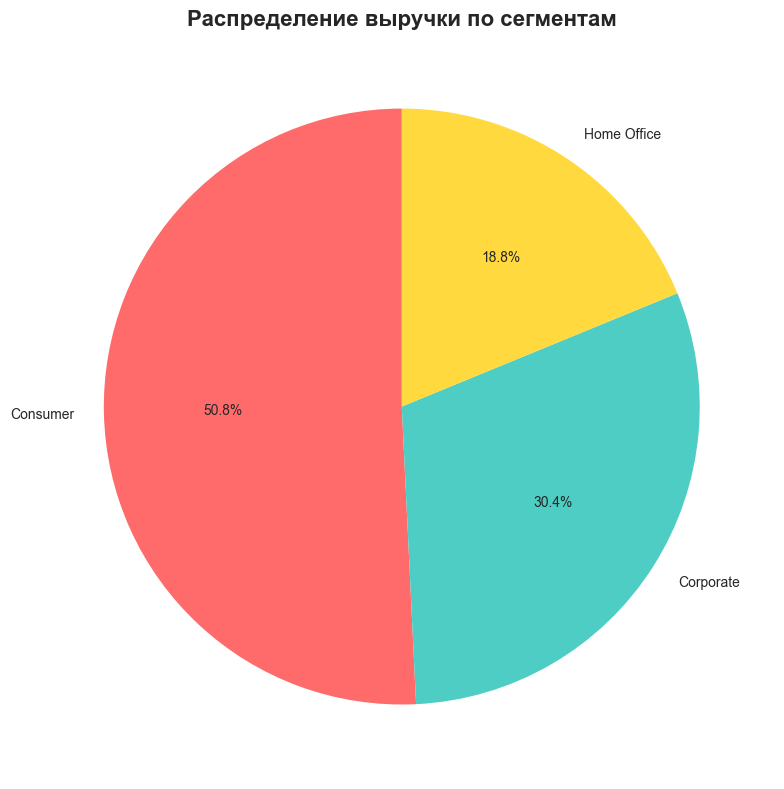

In [12]:
segment_sales = df.groupby('segment')['sales'].sum()

plt.figure(figsize=(8, 8))
plt.pie(segment_sales.values, labels=segment_sales.index, autopct='%1.1f%%',
        startangle=90, colors=['#FF6B6B', '#4ECDC4', '#FFD93D'])
plt.title('Распределение выручки по сегментам', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Выводы:**

- Consumer сегмент генерирует основную долю выручки

- Corporate и Home Office показывают меньшие, но стабильные объёмы

- Потенциал роста в развитии программ лояльности для Consumer сегмента

## 6. Сезонность продаж

Анализ продаж в разрезе категорий и месяцев для выявления сезонных паттернов.

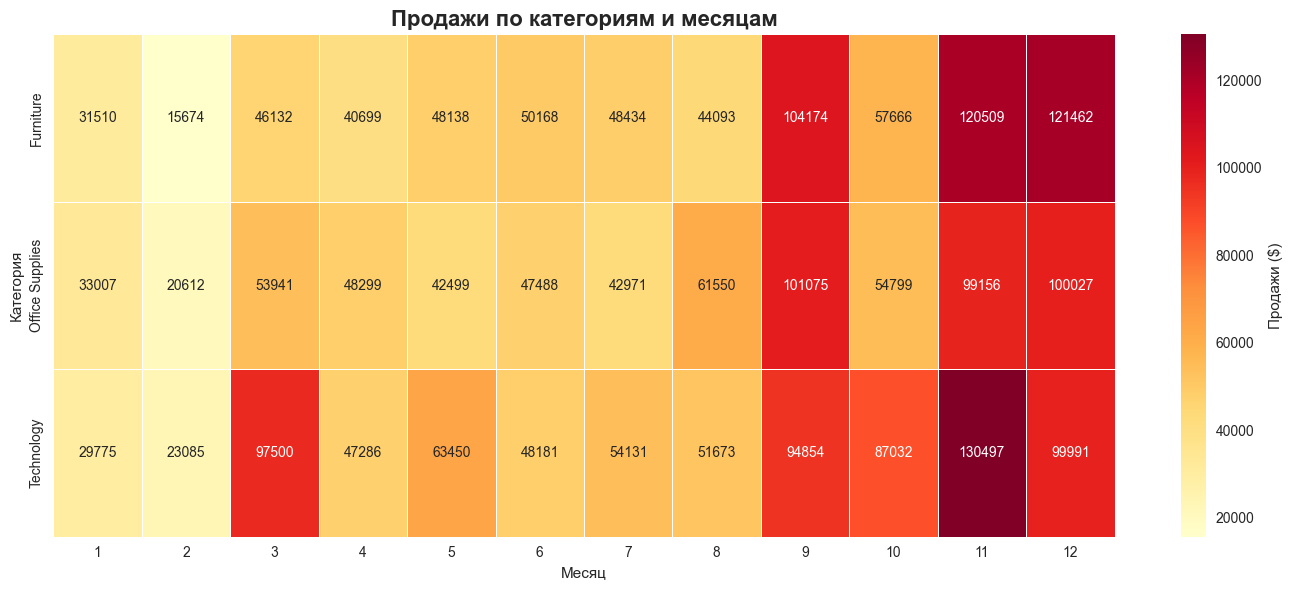

In [14]:
df['month'] = pd.to_datetime(df['order_date']).dt.month

pivot_table = df.pivot_table(values='sales', index='category', 
                               columns='month', aggfunc='sum', fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Продажи ($)'})
plt.title('Продажи по категориям и месяцам', fontsize=16, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

**Выводы:**

- Заметный рост продаж в конце года (ноябрь-декабрь) - сезон праздничных покупок

- Technology показывает стабильный спрос в течение года

- Летние месяцы демонстрируют некоторое снижение активности

---

## Итоговые выводы и рекомендации

### Ключевые находки:

1. **Выручка:** $2.26 млн за период 2015-2018 гг.

2. **Рост:** Позитивная динамика с приростом 50% за 3 года

3. **Лидер по категориям:** Technology (36% выручки)

4. **География:** California, New York и Texas - топ-3 региона (40% выручки)

5. **Клиенты:** Consumer сегмент - основа бизнеса

### Рекомендации:

**Продуктовая стратегия:**
- Расширение ассортимента Technology товаров
- Анализ причин спада 2016 года для предотвращения повторения

**Маркетинг:**
- Усиление присутствия в топ-3 штатах
- Программа лояльности для Consumer сегмента
- Использование сезонности для планирования промо-акций

**Развитие:**
- Потенциал роста в Corporate сегменте
- Географическая экспансия в перспективные регионы